# Model Training & Tunning - Credit Card Fraud Detection

In [78]:
# Import librarys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random 
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix as sk_confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, confusion_matrix, precision_recall_curve, precision_score, recall_score
from imblearn.over_sampling import RandomOverSampler

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [23]:
# Load the dataset

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "creditcard.csv"
MODEL_PATH = PROJECT_ROOT / "models"


In [24]:
cut_data = raw_data.drop(
    ["Time", "Amount", "V28", "V27", "V26", "V25", "V24", "V23", "V22"], axis=1
)

In [25]:
X = cut_data.drop("Class", axis=1)
y = cut_data["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
input_shape = X_train.shape[1]

# Base Neural Network Model

input = keras.layers.Input(shape=(input_shape,))
x = keras.layers.Dense(16, activation='relu')(input)
x = keras.layers.Dense(32, activation='relu')(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dense(16, activation='relu')(x)
output = keras.layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,065 (15.88 KB)

 Trainable params: 4,065 (15.88 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,verbose=1,
    validation_split=0.3,
    callbacks=[early_stopping])

Epoch 1/10
4985/4985 ━━━━━━━━━━━━━━━━━━━━ 3s 480us/step - accuracy: 0.9988 - loss: 0.0095 - precision_3: 0.6733 - recall_3: 0.6190 - val_accuracy: 0.9995 - val_loss: 0.0037 - val_precision_3: 0.9057 - val_recall_3: 0.7934
Epoch 2/10
4985/4985 ━━━━━━━━━━━━━━━━━━━━ 2s 440us/step - accuracy: 0.9994 - loss: 0.0035 - precision_3: 0.8490 - recall_3: 0.7619 - val_accuracy: 0.9995 - val_loss: 0.0036 - val_precision_3: 0.9118 - val_recall_3: 0.7686
Epoch 3/10
4985/4985 ━━━━━━━━━━━━━━━━━━━━ 2s 428us/step - accuracy: 0.9994 - loss: 0.0033 - precision_3: 0.8566 - recall_3: 0.7656 - val_accuracy: 0.9995 - val_loss: 0.0032 - val_precision_3: 0.8962 - val_recall_3: 0.7851
Epoch 4/10
4985/4985 ━━━━━━━━━━━━━━━━━━━━ 2s 436us/step - accuracy: 0.9994 - loss: 0.0031 - precision_3: 0.8455 - recall_3: 0.7619 - val_accuracy: 0.9995 - val_loss: 0.0030 - val_precision_3: 0.8818 - val_recall_3: 0.8017
Epoch 5/10
4985/4985 ━━━━━━━━━━━━━━━━━━━━ 2s 420us/step - accuracy: 0.9994 - loss: 0.0029 - precision_3: 0.8531 

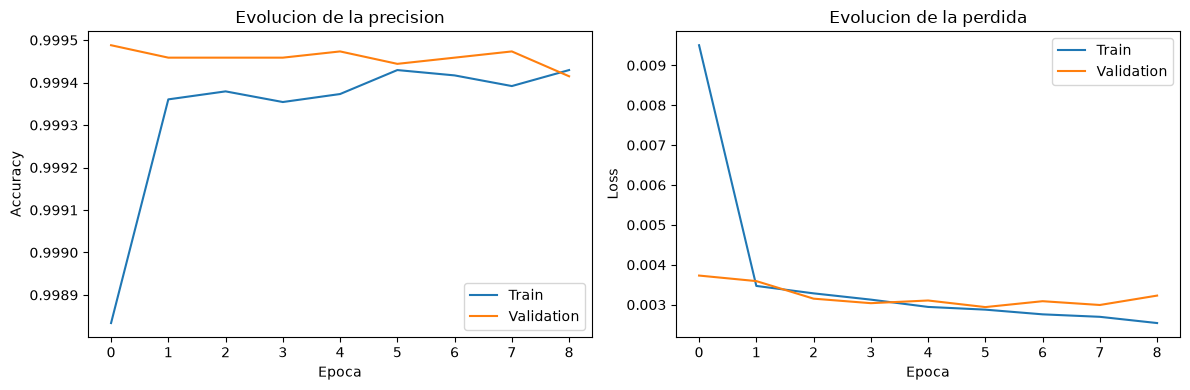

In [32]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Evolucion de la precision")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Evolucion de la perdida")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 170us/step


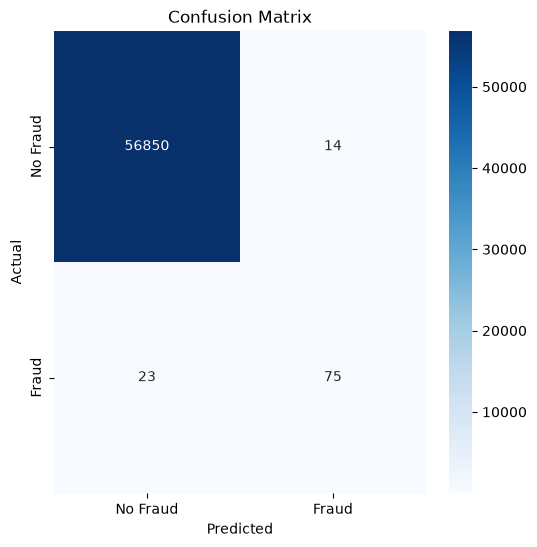

In [33]:
confusion_matrix = tf.math.confusion_matrix(y_test, model.predict(X_test).round())

plt.figure(figsize=(6, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')    
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Neural Network - Hyperparameter Tuning Function

def build_model(hp):
    input_shape = X_train.shape[1]

    input = keras.layers.Input(shape=(input_shape,))
    x = keras.layers.Dense(16, activation='relu')(input)
    x = keras.layers.Dense(hp.Int('HL3_Neurons', min_value=16, max_value= 64), activation='relu')(x)
    x = keras.layers.Dropout(hp.Float('Dropout_Rate1', min_value=0.1, max_value=0.5, step=0.1))(x)
    x = keras.layers.Dense(hp.Int('HL4_Neurons', min_value=16, max_value= 64), activation='relu')(x)
    x = keras.layers.Dropout(hp.Float('Dropout_Rate2', min_value=0.1, max_value=0.5, step=0.1))(x)
    x = keras.layers.Dense(16, activation='relu')(x)
    output = keras.layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=input, outputs=output)

    learning_rate = hp.Choice(
            "learning_rate",
            values=[1e-2, 1e-3, 1e-4],
        )


    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    return model

In [39]:
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=10,
    executions_per_trial=1,
    directory=MODEL_PATH,
    project_name="Credit_Card_Fraud_Detection",
    overwrite=True,
    seed=42,
)

tuner.search_space_summary()

early_stopping_tuner = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

tuner.search(
    X_train,
    y_train,
    validation_split=0.2,  # Reserva el 20% de los datos para validación
    epochs=15,
    callbacks=[early_stopping_tuner],
    shuffle=False,
    verbose=1,
)

Trial 10 Complete [00h 00m 23s]
val_accuracy: 0.9993855357170105

Best val_accuracy So Far: 0.9994513988494873
Total elapsed time: 00h 04m 24s


In [40]:
#Best hyperparameters from the tuner

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

best_model = tuner.hypermodel.build(best_hp)

Test loss: 0.0030
Test accuracy: 0.9994


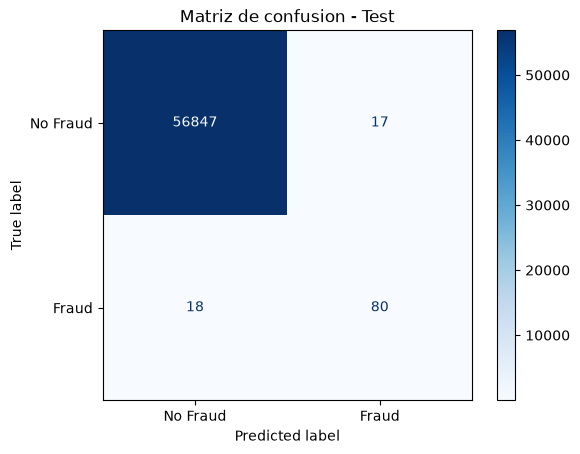

              precision    recall  f1-score   support

    No Fraud       1.00      1.00      1.00     56864
       Fraud       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [42]:
best_model = tuner.hypermodel.build(best_hp)

best_model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stopping_tuner],
    verbose=0,
)

CLASS_NAMES = ["No Fraud", "Fraud"]

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test.to_numpy(dtype=np.float32), y_test.to_numpy(dtype=np.int32))
).batch(1024)

test_loss, test_accuracy, _, _ = best_model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

y_pred_prob = best_model.predict(test_ds, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)
y_true = np.concatenate(
    [labels.numpy().ravel() for _, labels in test_ds]
).astype(int)

cm = sk_confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusion - Test")
plt.show()

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=CLASS_NAMES,
        zero_division=0,
    )
)

In [44]:
#Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=500,
    criterion="log_loss",
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=3,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
    )

    #train model
rf_model.fit(X_train, y_train)

    #predict
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

    #confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.9960
[[56647   217]
 [   11    87]]


In [46]:
#XGBoost Model

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=250,
    learning_rate=0.01,
    max_depth=7,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric=["logloss", "auc"],
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)

y_pred_xgb = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred_xgb)
print(cm)

evals_result = xgb_model.evals_result()



Accuracy: 0.9971
[[56716   148]
 [   18    80]]


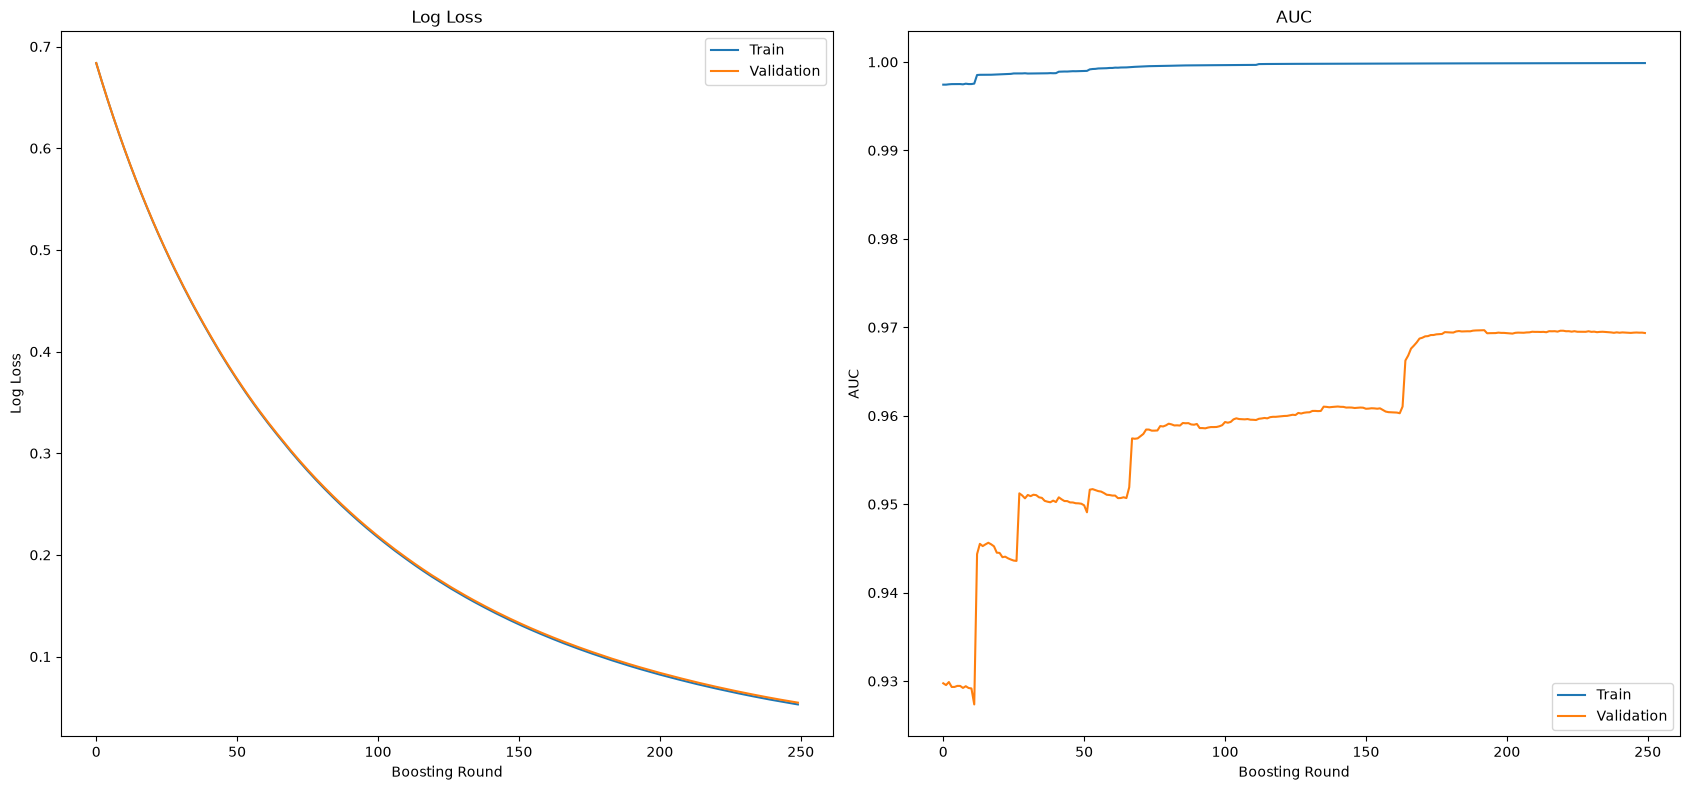

In [47]:
plt.figure(figsize=(17, 8))

plt.subplot(1, 2, 1)
plt.plot(evals_result["validation_0"]["logloss"], label="Train")
plt.plot(evals_result["validation_1"]["logloss"], label="Validation")
plt.title("Log Loss")
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(evals_result["validation_0"]["auc"], label="Train")
plt.plot(evals_result["validation_1"]["auc"], label="Validation")
plt.title("AUC")
plt.xlabel("Boosting Round")
plt.ylabel("AUC")
plt.legend()

plt.tight_layout()
plt.show()

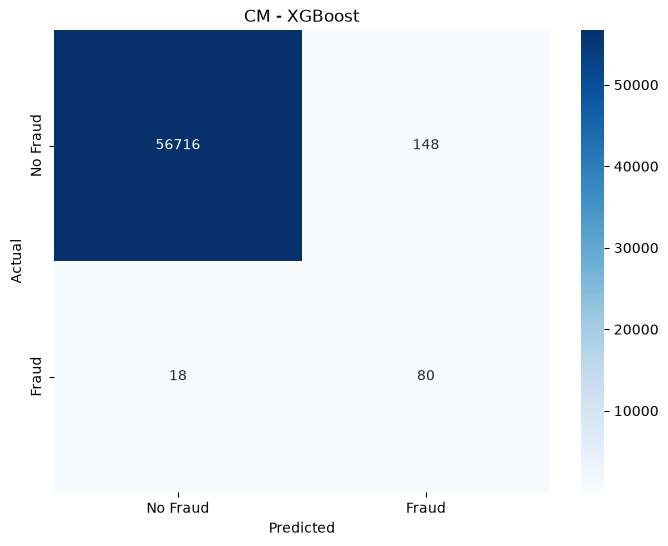

In [51]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues', xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CM - XGBoost')
plt.show()

Metric,Accuracy,F1 Macro,F1 Weighted
Model,,,
Neural Network,0.9994,0.9101,0.9994
Random Forest,0.9960,0.7154,0.9970
XGBoost,0.9971,0.7447,0.9977


Metric                   F1 Score  Precision  Recall
Model          Class                                
Neural Network Fraud       0.8205     0.8247  0.8163
               No Fraud    0.9997     0.9997  0.9997
Random Forest  Fraud       0.4328     0.2862  0.8878
               No Fraud    0.9980     0.9998  0.9962
XGBoost        Fraud       0.4908     0.3509  0.8163
               No Fraud    0.9985     0.9997  0.9974

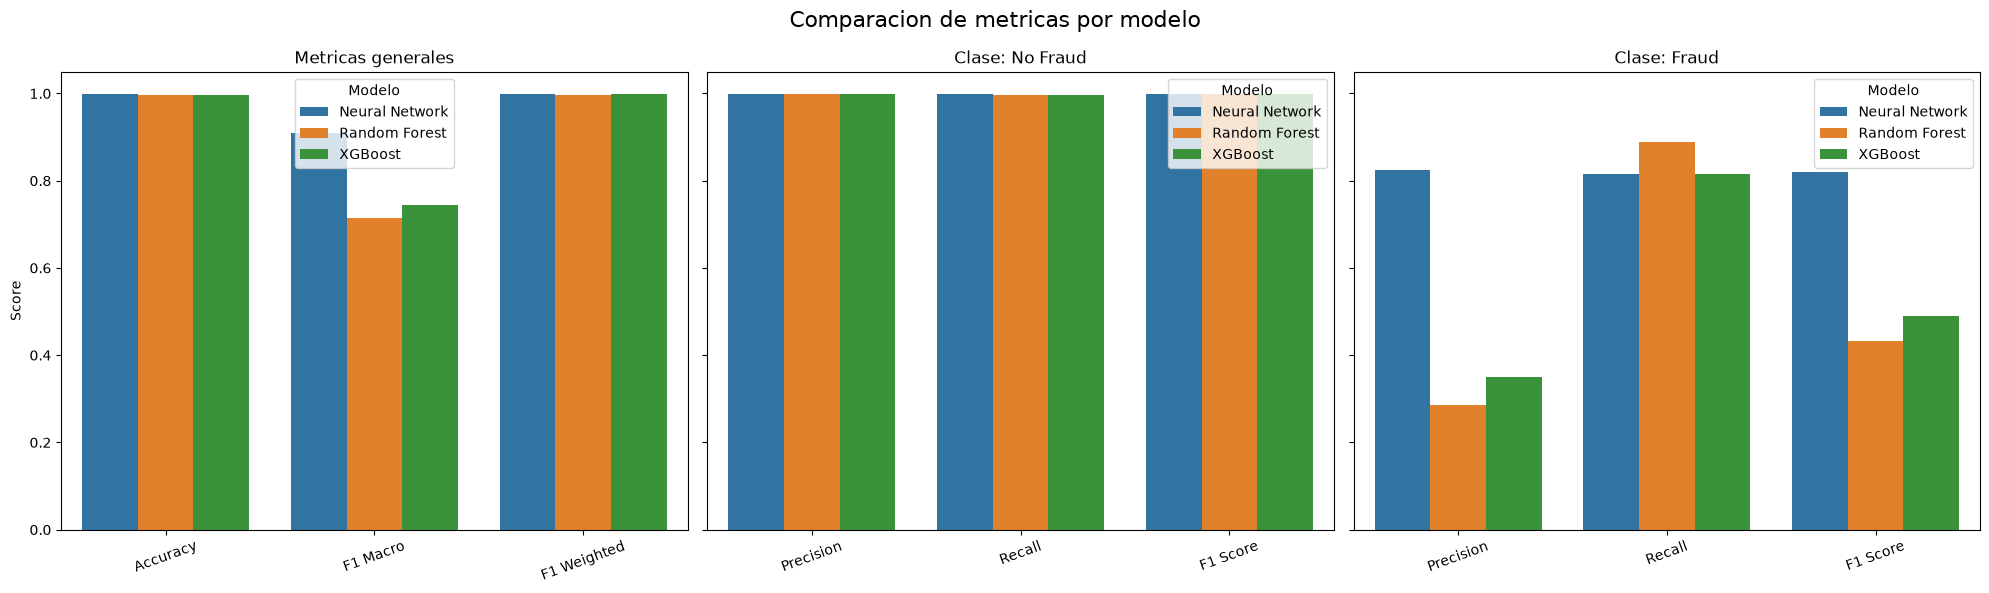

In [53]:
CLASS_NAMES = ["No Fraud", "Fraud"]

model_predictions = {
    "Neural Network": (best_model.predict(X_test.to_numpy(dtype=np.float32), verbose=0).ravel() >= 0.5).astype(int),
    "Random Forest": rf_model.predict(X_test),
    "XGBoost": xgb_model.predict(X_test),
}

overall_metrics = []
class_metrics = []

for model_name, predictions in model_predictions.items():
    y_pred_model = np.asarray(predictions).astype(int)

    overall_metrics.extend([
        {"Model": model_name, "Metric": "Accuracy", "Score": accuracy_score(y_test, y_pred_model)},
        {"Model": model_name, "Metric": "F1 Macro", "Score": f1_score(y_test, y_pred_model, average="macro", zero_division=0)},
        {"Model": model_name, "Metric": "F1 Weighted", "Score": f1_score(y_test, y_pred_model, average="weighted", zero_division=0)},
    ])

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        y_pred_model,
        labels=[0, 1],
        zero_division=0,
    )

    for class_id, class_name in enumerate(CLASS_NAMES):
        class_metrics.extend([
            {"Model": model_name, "Class": class_name, "Metric": "Precision", "Score": precision[class_id]},
            {"Model": model_name, "Class": class_name, "Metric": "Recall", "Score": recall[class_id]},
            {"Model": model_name, "Class": class_name, "Metric": "F1 Score", "Score": f1[class_id]},
        ])

overall_metrics_df = pd.DataFrame(overall_metrics)
class_metrics_df = pd.DataFrame(class_metrics)

display(overall_metrics_df.pivot_table(index="Model", columns="Metric", values="Score").round(4))
display(class_metrics_df.pivot_table(index=["Model", "Class"], columns="Metric", values="Score").round(4))

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

sns.barplot(data=overall_metrics_df, x="Metric", y="Score", hue="Model", ax=axes[0])
axes[0].set_title("Metricas generales")
axes[0].set_xlabel("")
axes[0].set_ylabel("Score")

for ax, class_name in zip(axes[1:], CLASS_NAMES):
    sns.barplot(
        data=class_metrics_df[class_metrics_df["Class"] == class_name],
        x="Metric",
        y="Score",
        hue="Model",
        ax=ax,
    )
    ax.set_title(f"Clase: {class_name}")
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes:
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Modelo")

plt.suptitle("Comparacion de metricas por modelo", fontsize=16)
plt.tight_layout()
plt.show()


In [61]:
# Original dataset testing on models

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=42,
    stratify=y_train_val
)

In [64]:
y_val_prob = xgb_model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_prob
)


target_recall = 0.97

valid_indices = np.where(recall[:-1] >= target_recall)[0]

best_threshold = thresholds[valid_indices[-1]]

print("Threshold seleccionado:", best_threshold)



y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(
    classification_report(
        y_test,
        y_test_pred
    )
)

print(
    confusion_matrix(
        y_test,
        y_test_pred
    )
)



Threshold seleccionado: 0.8791706
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.66      0.81      0.72        98

    accuracy                           1.00     56962
   macro avg       0.83      0.90      0.86     56962
weighted avg       1.00      1.00      1.00     56962

[[56823    41]
 [   19    79]]


In [75]:
##NN

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=42,
    stratify=y_train_val
)


ros = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train,
    y_train
)

lr = best_hp.get("learning_rate")

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=lr
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(
            curve="PR",
            name="pr_auc"
        )
    ]
)

history = best_model.fit(
    X_train_resampled,
    y_train_resampled,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)




tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective=kt.Objective(
        "val_pr_auc",
        direction="max"
    ),
    max_trials=10,
    executions_per_trial=1,
    directory=MODEL_PATH,
    project_name="Credit_Card_Fraud_Detection",
    overwrite=True,
    seed=42
)



Epoch 1/30
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 5s 404us/step - loss: 0.0803 - pr_auc: 0.9957 - precision: 0.9797 - recall: 0.9593 - val_loss: 0.0355 - val_pr_auc: 0.6809 - val_precision: 0.1102 - val_recall: 0.8734
Epoch 2/30
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 5s 418us/step - loss: 0.0282 - pr_auc: 0.9989 - precision: 0.9884 - recall: 0.9929 - val_loss: 0.0218 - val_pr_auc: 0.6727 - val_precision: 0.1965 - val_recall: 0.8481
Epoch 3/30
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 4s 392us/step - loss: 0.0159 - pr_auc: 0.9993 - precision: 0.9929 - recall: 0.9980 - val_loss: 0.0177 - val_pr_auc: 0.6696 - val_precision: 0.2895 - val_recall: 0.8354
Epoch 4/30
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 4s 391us/step - loss: 0.0114 - pr_auc: 0.9993 - precision: 0.9950 - recall: 0.9992 - val_loss: 0.0175 - val_pr_auc: 0.6651 - val_precision: 0.3497 - val_recall: 0.8101
Epoch 5/30
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 5s 404us/step - loss: 0.0089 - pr_auc: 0.9994 - precision: 0.9962 - recall: 0.9996 - val_loss: 0.0186 - val_

In [76]:
# 1. Probabilidades en VALIDATION
y_val_prob = best_model.predict(
    X_val.to_numpy(dtype=np.float32),
    verbose=0
).ravel()

from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_prob
)

target_recall = 0.97

valid_idx = np.where(recall[:-1] >= target_recall)[0]

best_threshold = thresholds[valid_idx[-1]]

print("Best threshold:", best_threshold)
print("Recall validation:", recall[valid_idx[-1]])
print("Precision validation:", precision[valid_idx[-1]])

# 2. Evaluación FINAL en TEST
y_test_prob = best_model.predict(
    X_test.to_numpy(dtype=np.float32),
    verbose=0
).ravel()

y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)


from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    y_test,
    y_test_pred,
    digits=4
))

print(confusion_matrix(
    y_test,
    y_test_pred
))



tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

print("Fraudes escapados:", fn)
print("Fraudes detectados:", tp)

Best threshold: 2.157642e-23
Recall validation: 0.9746835443037974
Precision validation: 0.0034996818471048088
              precision    recall  f1-score   support

           0     0.9999    0.5189    0.6832     56864
           1     0.0035    0.9796    0.0070        98

    accuracy                         0.5197     56962
   macro avg     0.5017    0.7492    0.3451     56962
weighted avg     0.9982    0.5197    0.6821     56962

[[29507 27357]
 [    2    96]]
True Negatives: 29507
False Positives: 27357
False Negatives: 2
True Positives: 96
Fraudes escapados: 2
Fraudes detectados: 96


In [80]:
# XGBoost with original dataset, train/validation/test split, and fraud recall target

xgb_original_X = raw_data.drop("Class", axis=1)
xgb_original_y = raw_data["Class"]

xgb_original_X_train_val, xgb_original_X_test, xgb_original_y_train_val, xgb_original_y_test = train_test_split(
    xgb_original_X,
    xgb_original_y,
    test_size=0.20,
    random_state=SEED,
    stratify=xgb_original_y,
)

xgb_original_X_train, xgb_original_X_val, xgb_original_y_train, xgb_original_y_val = train_test_split(
    xgb_original_X_train_val,
    xgb_original_y_train_val,
    test_size=0.20,
    random_state=SEED,
    stratify=xgb_original_y_train_val,
)

target_fraud_recall = 0.95
base_scale_pos_weight = (xgb_original_y_train == 0).sum() / (xgb_original_y_train == 1).sum()
positive_weight_multipliers = [1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 10.0]

xgb_original_models = {}
xgb_original_results = []

for multiplier in positive_weight_multipliers:
    scale_pos_weight = base_scale_pos_weight * multiplier

    candidate_model = XGBClassifier(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=3,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_lambda=2.0,
        reg_alpha=0.10,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=SEED,
        n_jobs=-1,
    )

    candidate_model.fit(
        xgb_original_X_train,
        xgb_original_y_train,
        eval_set=[(xgb_original_X_val, xgb_original_y_val)],
        verbose=False,
    )

    xgb_original_models[multiplier] = candidate_model
    val_prob = candidate_model.predict_proba(xgb_original_X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(xgb_original_y_val, val_prob)

    threshold_metrics = pd.DataFrame({
        "threshold": thresholds,
        "precision_fraud": precision[:-1],
        "recall_fraud": recall[:-1],
    })
    threshold_metrics["f1_fraud"] = (
        2
        * threshold_metrics["precision_fraud"]
        * threshold_metrics["recall_fraud"]
        / (threshold_metrics["precision_fraud"] + threshold_metrics["recall_fraud"])
    ).fillna(0)

    valid_thresholds = threshold_metrics[threshold_metrics["recall_fraud"] >= target_fraud_recall]
    if valid_thresholds.empty:
        selected_threshold = threshold_metrics.sort_values(
            ["recall_fraud", "f1_fraud"],
            ascending=False,
        ).iloc[0]
        meets_target_recall = False
    else:
        selected_threshold = valid_thresholds.sort_values("f1_fraud", ascending=False).iloc[0]
        meets_target_recall = True

    val_pred = (val_prob >= selected_threshold["threshold"]).astype(int)

    xgb_original_results.append({
        "multiplier": multiplier,
        "scale_pos_weight": scale_pos_weight,
        "threshold": selected_threshold["threshold"],
        "meets_target_recall": meets_target_recall,
        "val_accuracy": accuracy_score(xgb_original_y_val, val_pred),
        "val_precision_fraud": precision_score(xgb_original_y_val, val_pred, pos_label=1, zero_division=0),
        "val_recall_fraud": recall_score(xgb_original_y_val, val_pred, pos_label=1, zero_division=0),
        "val_f1_fraud": f1_score(xgb_original_y_val, val_pred, pos_label=1, zero_division=0),
    })

xgb_original_results_df = pd.DataFrame(xgb_original_results)

target_results = xgb_original_results_df[xgb_original_results_df["meets_target_recall"]]
if target_results.empty:
    xgb_original_best_row = xgb_original_results_df.sort_values(
        ["val_recall_fraud", "val_f1_fraud"],
        ascending=False,
    ).iloc[0]
else:
    xgb_original_best_row = target_results.sort_values("val_f1_fraud", ascending=False).iloc[0]

xgb_original_best_model = xgb_original_models[xgb_original_best_row["multiplier"]]
xgb_original_best_threshold = xgb_original_best_row["threshold"]

display(xgb_original_results_df.sort_values("val_f1_fraud", ascending=False).round(4))
print("Best multiplier:", xgb_original_best_row["multiplier"])
print("Best threshold:", xgb_original_best_threshold)
print("Validation fraud recall:", round(xgb_original_best_row["val_recall_fraud"], 4))
print("Validation fraud F1:", round(xgb_original_best_row["val_f1_fraud"], 4))

xgb_original_test_prob = xgb_original_best_model.predict_proba(xgb_original_X_test)[:, 1]
xgb_original_test_pred = (xgb_original_test_prob >= xgb_original_best_threshold).astype(int)

print("\nTest results")
print(classification_report(
    xgb_original_y_test,
    xgb_original_test_pred,
    target_names=["No Fraud", "Fraud"],
    digits=4,
    zero_division=0,
))

xgb_original_cm = confusion_matrix(xgb_original_y_test, xgb_original_test_pred)
tn, fp, fn, tp = xgb_original_cm.ravel()

print("Confusion matrix:")
print(xgb_original_cm)
print("Fraudes escapados:", fn)
print("Fraudes detectados:", tp)




,multiplier,scale_pos_weight,threshold,meets_target_recall,val_accuracy,val_precision_fraud,val_recall_fraud,val_f1_fraud
2,2.0,1155.3079,0.0011,True,0.8899,0.0149,0.962,0.0294
4,5.0,2888.2698,0.0010,True,0.8617,0.0119,0.962,0.0236
0,1.0,577.6540,0.0007,True,0.8586,0.0117,0.962,0.0230
1,1.5,866.4810,0.0007,True,0.8461,0.0107,0.962,0.0212
6,10.0,5776.5397,0.0008,True,0.8392,0.0103,0.962,0.0203
3,3.0,1732.9619,0.0005,True,0.8108,0.0087,0.962,0.0173
5,8.0,4621.2317,0.0005,True,0.8032,0.0084,0.962,0.0167


Best multiplier: 2.0
Best threshold: 0.0011275438591837883
Validation fraud recall: 0.962
Validation fraud F1: 0.0294

Test results
              precision    recall  f1-score   support

    No Fraud     0.9999    0.8881    0.9407     56864
       Fraud     0.0144    0.9490    0.0284        98

    accuracy                         0.8882     56962
   macro avg     0.5072    0.9186    0.4845     56962
weighted avg     0.9982    0.8882    0.9391     56962

Confusion matrix:
[[50503  6361]
 [    5    93]]
Fraudes escapados: 5
Fraudes detectados: 93


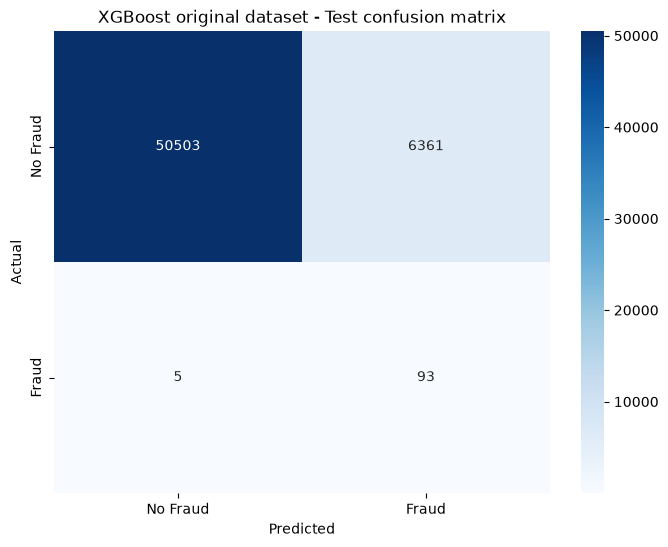

In [81]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    xgb_original_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Fraud", "Fraud"],
    yticklabels=["No Fraud", "Fraud"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost original dataset - Test confusion matrix")
plt.show()

In [82]:
# XGBoost threshold tuning: keep fraud recall >= 95% while reducing false positives

from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

xgb_fp_X = raw_data.drop("Class", axis=1)
xgb_fp_y = raw_data["Class"]

xgb_fp_X_train_val, xgb_fp_X_test, xgb_fp_y_train_val, xgb_fp_y_test = train_test_split(
    xgb_fp_X,
    xgb_fp_y,
    test_size=0.20,
    random_state=SEED,
    stratify=xgb_fp_y,
)

xgb_fp_X_train, xgb_fp_X_val, xgb_fp_y_train, xgb_fp_y_val = train_test_split(
    xgb_fp_X_train_val,
    xgb_fp_y_train_val,
    test_size=0.20,
    random_state=SEED,
    stratify=xgb_fp_y_train_val,
)

target_recall = 0.90
base_pos_weight = (xgb_fp_y_train == 0).sum() / (xgb_fp_y_train == 1).sum()
pos_weight_multipliers = [1.0, 1.25, 1.5, 2.0, 3.0, 5.0, 8.0]

xgb_fp_models = {}
xgb_fp_model_rows = []
xgb_fp_threshold_rows = []

for multiplier in pos_weight_multipliers:
    pos_weight = base_pos_weight * multiplier
    model_key = f"spw_x{multiplier:g}"

    xgb_fp_model = XGBClassifier(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=3,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_lambda=3.0,
        reg_alpha=0.10,
        scale_pos_weight=pos_weight,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=SEED,
        n_jobs=-1,
    )

    xgb_fp_model.fit(
        xgb_fp_X_train,
        xgb_fp_y_train,
        eval_set=[(xgb_fp_X_val, xgb_fp_y_val)],
        verbose=False,
    )

    xgb_fp_models[model_key] = xgb_fp_model
    val_prob = xgb_fp_model.predict_proba(xgb_fp_X_val)[:, 1]
    pr_auc = average_precision_score(xgb_fp_y_val, val_prob)
    precision, recall, thresholds = precision_recall_curve(xgb_fp_y_val, val_prob)

    precision_at_threshold = precision[:-1]
    recall_at_threshold = recall[:-1]
    positives_val = int((xgb_fp_y_val == 1).sum())

    true_positives = np.rint(recall_at_threshold * positives_val).astype(int)
    false_negatives = positives_val - true_positives
    false_positives = np.where(
        precision_at_threshold > 0,
        np.rint(true_positives / precision_at_threshold - true_positives),
        0,
    ).astype(int)
    f1_at_threshold = np.where(
        precision_at_threshold + recall_at_threshold > 0,
        2 * precision_at_threshold * recall_at_threshold / (precision_at_threshold + recall_at_threshold),
        0,
    )

    xgb_fp_threshold_rows.extend(
        pd.DataFrame({
            "model_key": model_key,
            "multiplier": multiplier,
            "scale_pos_weight": pos_weight,
            "threshold": thresholds,
            "precision_fraud": precision_at_threshold,
            "recall_fraud": recall_at_threshold,
            "f1_fraud": f1_at_threshold,
            "false_positives": false_positives,
            "false_negatives": false_negatives,
            "true_positives": true_positives,
            "pr_auc": pr_auc,
        }).to_dict("records")
    )

    xgb_fp_model_rows.append({
        "model_key": model_key,
        "multiplier": multiplier,
        "scale_pos_weight": pos_weight,
        "validation_pr_auc": pr_auc,
    })

xgb_fp_model_summary_df = pd.DataFrame(xgb_fp_model_rows).sort_values(
    "validation_pr_auc",
    ascending=False,
)
xgb_fp_thresholds_df = pd.DataFrame(xgb_fp_threshold_rows)
xgb_fp_valid_thresholds_df = xgb_fp_thresholds_df[xgb_fp_thresholds_df["recall_fraud"] >= target_recall]

if xgb_fp_valid_thresholds_df.empty:
    print("No threshold reached the target recall on validation. Showing the closest options.")
    xgb_fp_best_row = xgb_fp_thresholds_df.sort_values(
        ["recall_fraud", "f1_fraud", "false_positives"],
        ascending=[False, False, True],
    ).iloc[0]
else:
    xgb_fp_best_row = xgb_fp_valid_thresholds_df.sort_values(
        ["f1_fraud", "false_positives", "precision_fraud", "pr_auc"],
        ascending=[False, True, False, False],
    ).iloc[0]

display(xgb_fp_model_summary_df.round(4))
display(
    xgb_fp_valid_thresholds_df.sort_values(
        ["f1_fraud", "false_positives", "precision_fraud"],
        ascending=[False, True, False],
    )
    .head(15)
    .round(4)
)

print("Selected model:", xgb_fp_best_row["model_key"])
print("Selected threshold:", xgb_fp_best_row["threshold"])
print("Validation recall fraud:", round(xgb_fp_best_row["recall_fraud"], 4))
print("Validation precision fraud:", round(xgb_fp_best_row["precision_fraud"], 4))
print("Validation F1 fraud:", round(xgb_fp_best_row["f1_fraud"], 4))
print("Validation false positives:", int(xgb_fp_best_row["false_positives"]))
print("Validation PR-AUC:", round(xgb_fp_best_row["pr_auc"], 4))

xgb_fp_best_model = xgb_fp_models[xgb_fp_best_row["model_key"]]
xgb_fp_best_threshold = xgb_fp_best_row["threshold"]

xgb_fp_test_prob = xgb_fp_best_model.predict_proba(xgb_fp_X_test)[:, 1]
xgb_fp_test_pred = (xgb_fp_test_prob >= xgb_fp_best_threshold).astype(int)
xgb_fp_test_cm = confusion_matrix(xgb_fp_y_test, xgb_fp_test_pred, labels=[0, 1])
tn, fp, fn, tp = xgb_fp_test_cm.ravel()



,model_key,multiplier,scale_pos_weight,validation_pr_auc
3,spw_x2,2.00,1155.3079,0.8289
1,spw_x1.25,1.25,722.0675,0.8277
2,spw_x1.5,1.50,866.4810,0.8275
0,spw_x1,1.00,577.6540,0.8243
4,spw_x3,3.00,1732.9619,0.8217
5,spw_x5,5.00,2888.2698,0.8206
6,spw_x8,8.00,4621.2317,0.8202


,model_key,multiplier,scale_pos_weight,threshold,precision_fraud,recall_fraud,f1_fraud,false_positives,false_negatives,true_positives,pr_auc
314469,spw_x8,8.0,4621.2317,0.0072,0.0617,0.9114,0.1157,1094,7,72,0.8202
314468,spw_x8,8.0,4621.2317,0.0071,0.0617,0.9114,0.1156,1095,7,72,0.8202
314467,spw_x8,8.0,4621.2317,0.0071,0.0616,0.9114,0.1155,1096,7,72,0.8202
314466,spw_x8,8.0,4621.2317,0.0071,0.0616,0.9114,0.1154,1097,7,72,0.8202
314465,spw_x8,8.0,4621.2317,0.0071,0.0615,0.9114,0.1153,1098,7,72,0.8202
314464,spw_x8,8.0,4621.2317,0.0071,0.0615,0.9114,0.1152,1099,7,72,0.8202
314463,spw_x8,8.0,4621.2317,0.0071,0.0614,0.9114,0.1151,1100,7,72,0.8202
314462,spw_x8,8.0,4621.2317,0.0071,0.0614,0.9114,0.1150,1101,7,72,0.8202
314461,spw_x8,8.0,4621.2317,0.0071,0.0613,0.9114,0.1149,1102,7,72,0.8202
314460,spw_x8,8.0,4621.2317,0.0071,0.0613,0.9114,0.1148,1103,7,72,0.8202


Selected model: spw_x8
Selected threshold: 0.007152053993195295
Validation recall fraud: 0.9114
Validation precision fraud: 0.0617
Validation F1 fraud: 0.1157
Validation false positives: 1094
Validation PR-AUC: 0.8202


In [83]:
print("\nFinal test results using validation-selected threshold")
print(classification_report(
    xgb_fp_y_test,
    xgb_fp_test_pred,
    target_names=["No Fraud", "Fraud"],
    digits=4,
    zero_division=0,
))
print("Test PR-AUC:", round(average_precision_score(xgb_fp_y_test, xgb_fp_test_prob), 4))
print("True negatives:", tn)
print("False positives:", fp)
print("False negatives / fraudes escapados:", fn)
print("True positives / fraudes detectados:", tp)


Final test results using validation-selected threshold
              precision    recall  f1-score   support

    No Fraud     0.9999    0.9751    0.9873     56864
       Fraud     0.0604    0.9286    0.1135        98

    accuracy                         0.9750     56962
   macro avg     0.5301    0.9518    0.5504     56962
weighted avg     0.9983    0.9750    0.9858     56962

Test PR-AUC: 0.8667
True negatives: 55449
False positives: 1415
False negatives / fraudes escapados: 7
True positives / fraudes detectados: 91


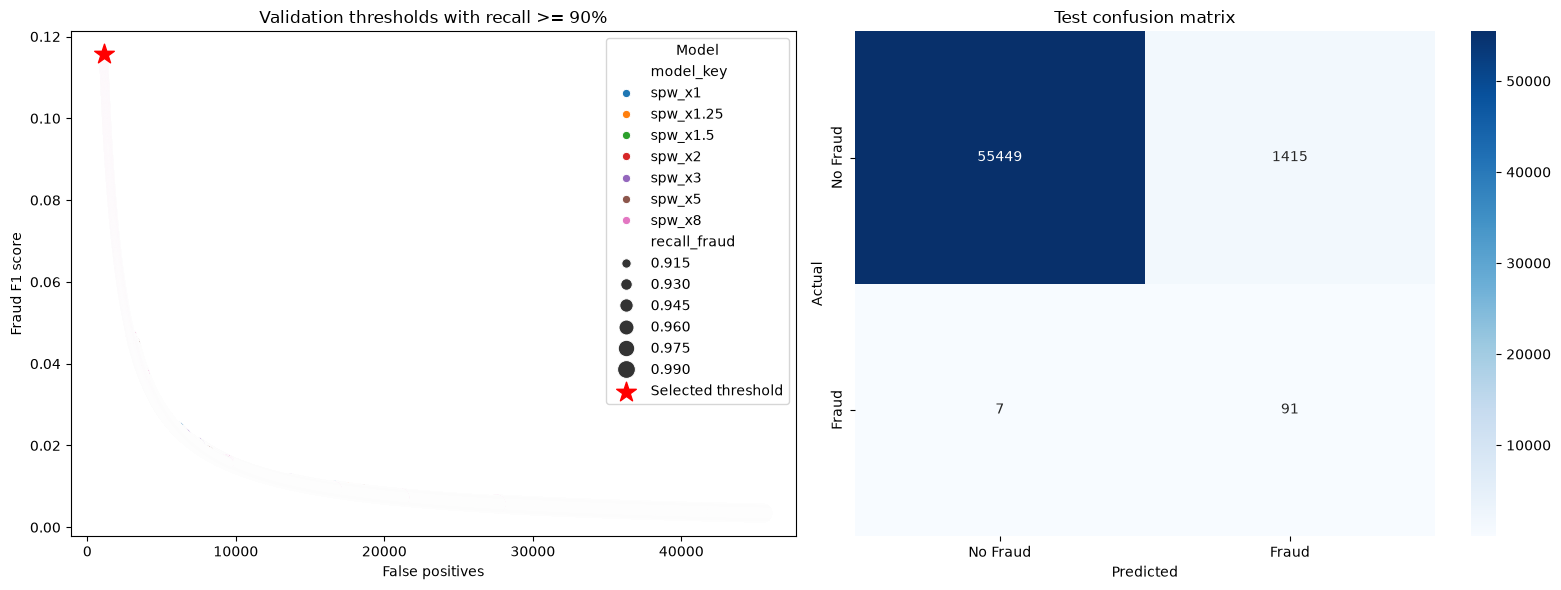

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=xgb_fp_valid_thresholds_df,
    x="false_positives",
    y="f1_fraud",
    hue="model_key",
    size="recall_fraud",
    sizes=(40, 180),
    ax=axes[0],
)
axes[0].scatter(
    xgb_fp_best_row["false_positives"],
    xgb_fp_best_row["f1_fraud"],
    color="red",
    s=220,
    marker="*",
    label="Selected threshold",
)
axes[0].set_title("Validation thresholds with recall >= 90%")
axes[0].set_xlabel("False positives")
axes[0].set_ylabel("Fraud F1 score")
axes[0].legend(title="Model")

sns.heatmap(
    xgb_fp_test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Fraud", "Fraud"],
    yticklabels=["No Fraud", "Fraud"],
    ax=axes[1],
)
axes[1].set_title("Test confusion matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()
